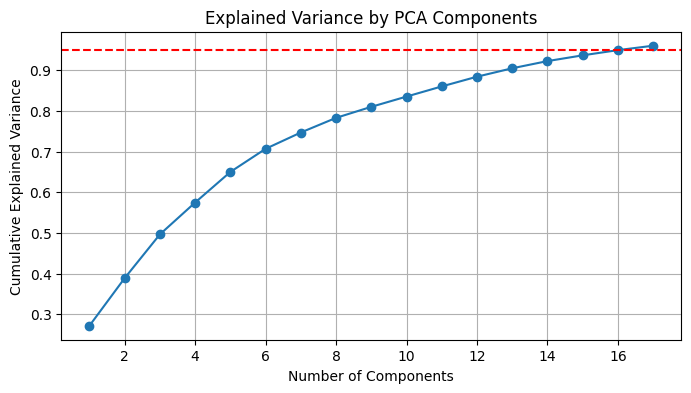

=== COMPREHENSIVE CLUSTERING ANALYSIS ===

1. OPTIMIZED KMEANS:

2. ENSEMBLE CLUSTERING:
Ensemble Clustering Score: 0.0709

3. GAUSSIAN MIXTURE MODELS:
GMM with 3 components: 0.1165
GMM with 4 components: 0.0704
GMM with 5 components: 0.0632
GMM with 6 components: 0.0455
GMM with 7 components: 0.0460

4. DBSCAN:
DBSCAN found only one cluster

=== BEST METHOD: KMeans ===
Best Silhouette Score: 0.1207


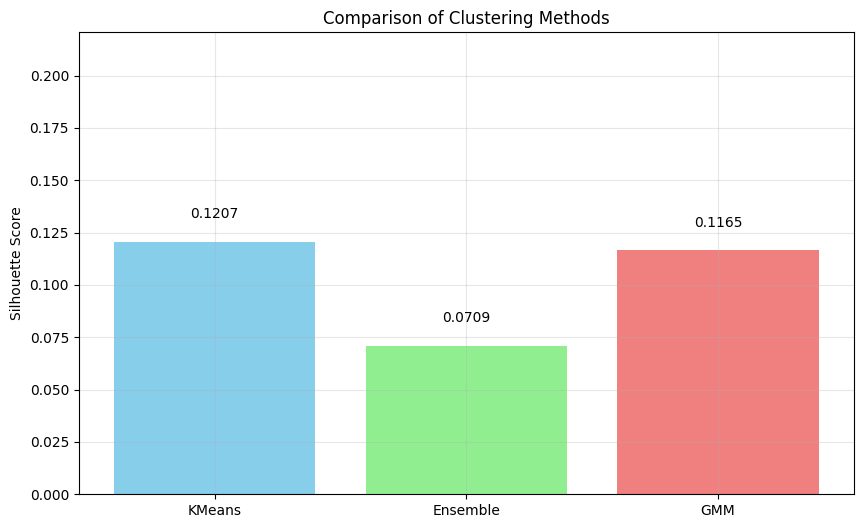

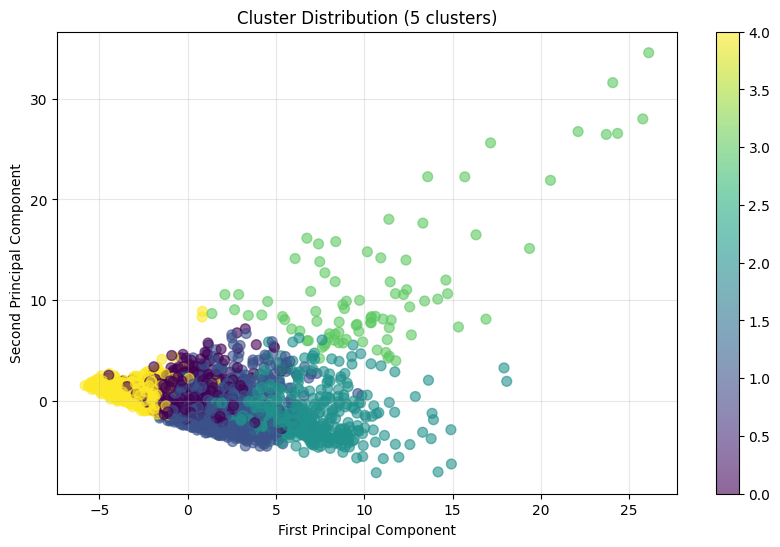

Beste Methode: KMeans
Bester Score: 0.1207

Cluster Verteilung:
cluster
0    1674
1    1924
2     434
3      87
4    1879
Name: count, dtype: int64


/Users/kiko/Desktop/github/traveltide/src/clustering.py:451: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feature, data=df_with_clusters, palette="Set2")


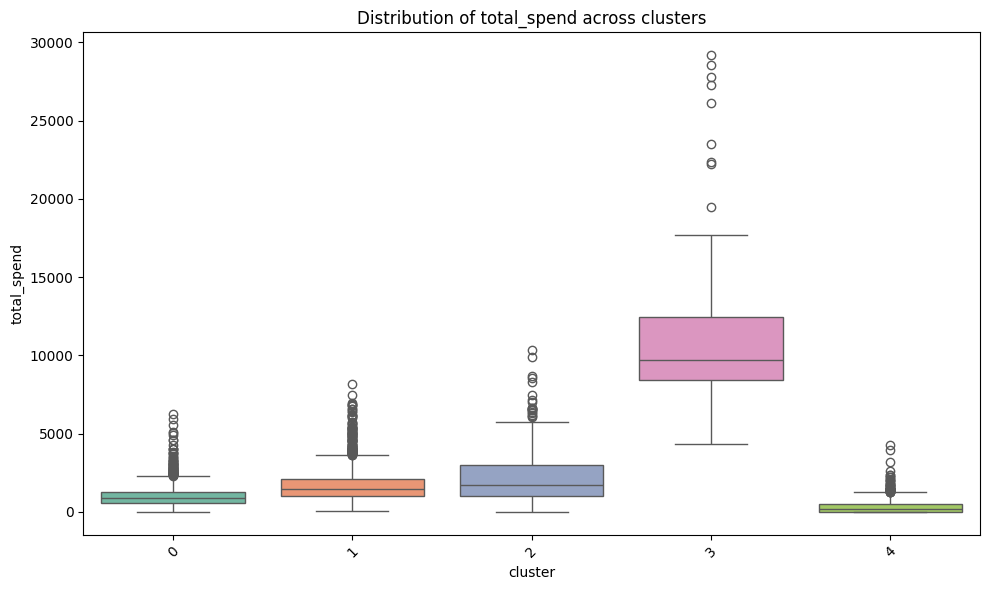

/Users/kiko/Desktop/github/traveltide/src/clustering.py:451: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y=feature, data=df_with_clusters, palette="Set2")


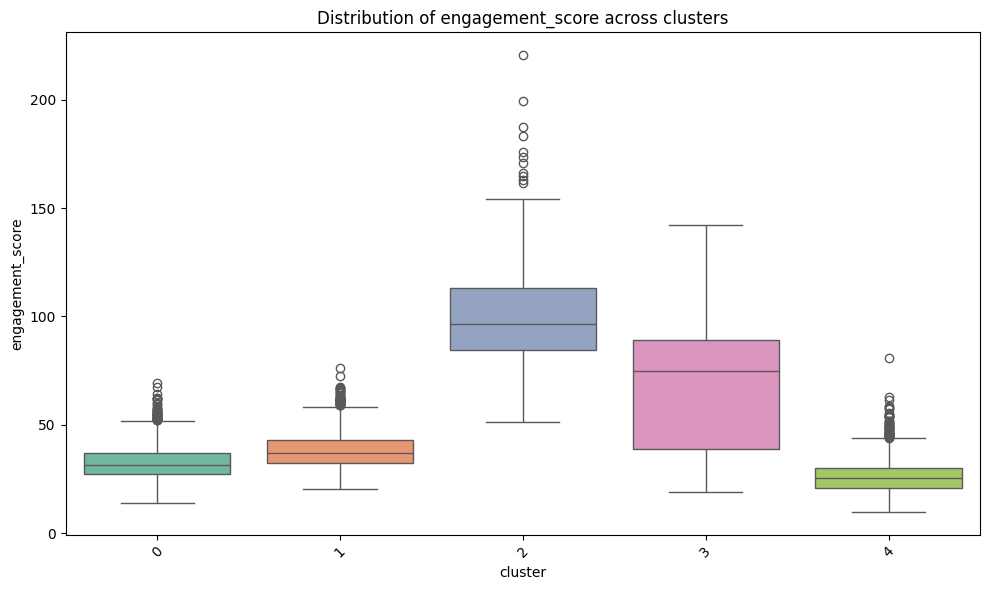

In [1]:
# In Ihrem Notebook
from src.feature_engineering import engineer_features_optimized, engineer_features_combined
from src.clustering import AdvancedSegmentationPipeline
from src.setup import get_base

df = get_base()

# 1. Optimierte Features erstellen
user_features_optimized = engineer_features_optimized(df)

# 2. Erweiterte Pipeline initialisieren
pipeline = AdvancedSegmentationPipeline(variance_threshold=0.95, max_clusters=10)

# 3. Features vorbereiten
features_scaled, features_df = pipeline.prepare_features(
    user_features_optimized,
    drop_cols=['first_booking', 'last_booking']  # Nicht-numerische Spalten entfernen
)

# 4. PCA durchführen
components, pca, explained_var = pipeline.run_pca(features_scaled)
pipeline.plot_explained_variance()

# 5. Umfassendes Clustering durchführen
best_labels, best_score, all_results = pipeline.run_comprehensive_clustering(
    target_clusters=5  # Optional: spezifische Cluster-Anzahl anstreben
)

# 6. Ergebnisse visualisieren
pipeline.plot_comparison(all_results)
pipeline.plot_clusters()

# 7. Cluster zuweisen und analysieren
df_with_clusters = pipeline.assign_clusters(features_df, best_labels)
cluster_means = pipeline.cluster_means(df_with_clusters)

print(f"Beste Methode: {pipeline.best_method}")
print(f"Bester Score: {pipeline.best_score:.4f}")
print("\nCluster Verteilung:")
print(df_with_clusters['cluster'].value_counts().sort_index())

# 8. Wichtige Features pro Cluster analysieren
pipeline.plot_cluster_feature(df_with_clusters, 'total_spend')
pipeline.plot_cluster_feature(df_with_clusters, 'engagement_score')